In [ ]:
# MEA Case 2 — Magnetoelastic Structural-Mode Reduced-Order Model

## Objective

Construct a fresh mechanically grounded magnetically forced structural model and determine whether its dominant response can be represented accurately by a first-mode reduced-order model.

The system is a cantilever beam subjected to a generalized magnetic actuator force.

The governing distributed model is based on Euler–Bernoulli beam mechanics,

\[
\rho A
\frac{\partial^2 w}{\partial t^2}
+
c_d
\frac{\partial w}{\partial t}
+
EI
\frac{\partial^4 w}{\partial x^4}
=
f_{\mathrm{mag}}(x,t),
\]

and the first-mode ROM is

\[
m_1\ddot q
+
c_1\dot q
+
k_1q
=
F_1(t).
\]

Case 2 is deliberately conventional: the second-order form arises directly from structural mechanics.

SyntaxError: invalid character '–' (U+2013) (3018200376.py, line 9)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

CASE2 = {
    "L_m": 0.050,
    "b_m": 0.010,
    "h_m": 0.001,

    "E_Pa": 200e9,
    "rho_kg_m3": 7800.0,

    "zeta": 0.02,

    # actuator force constant
    # F = K_F * I
    "K_F_N_A": 0.20,

    # baseline current amplitude
    "I0_A": 0.10,
}

BETA1 = 1.875104068711961

In [2]:
L = CASE2["L_m"]
b = CASE2["b_m"]
h = CASE2["h_m"]

E = CASE2["E_Pa"]
rho = CASE2["rho_kg_m3"]

A = b*h
I = b*h**3/12

m_beam = rho*A*L

print("Area =", A, "m^2")
print("Second moment =", I, "m^4")
print("Beam mass =", m_beam, "kg")

Area = 1e-05 m^2
Second moment = 8.333333333333334e-13 m^4
Beam mass = 0.0039000000000000003 kg


In [3]:
omega1 = (
    BETA1**2
    *
    np.sqrt(
        E*I
        /
        (
            rho*A*L**4
        )
    )
)

f1 = omega1/(2*np.pi)

m1 = 0.236 * m_beam

k1 = m1 * omega1**2

zeta1 = CASE2["zeta"]

c1 = (
    2*zeta1*m1*omega1
)

print(
    f"First natural frequency = "
    f"{f1:.3f} Hz"
)

print(
    f"Effective modal mass = "
    f"{m1:.6e} kg"
)

print(
    f"Modal stiffness = "
    f"{k1:.3f} N/m"
)

print(
    f"Modal damping = "
    f"{c1:.6f} N s/m"
)

First natural frequency = 327.196 Hz
Effective modal mass = 9.204000e-04 kg
Modal stiffness = 3890.024 N/m
Modal damping = 0.075688 N s/m


In [4]:
BETAS = np.array([
    1.8751040687,
    4.6940911330,
    7.8547574382,
    10.9955407349
])

omega_modes = (
    BETAS**2
    *
    np.sqrt(
        E*I
        /
        (
            rho*A*L**4
        )
    )
)

f_modes = (
    omega_modes
    /
    (2*np.pi)
)

pd.DataFrame({
    "mode": np.arange(1,5),
    "beta": BETAS,
    "f_Hz": f_modes
})

,mode,beta,f_Hz
0,1,1.875104,327.195972
1,2,4.694091,2050.502156
2,3,7.854757,5741.465411
3,4,10.995541,11250.980709


In [5]:
NMODES = 4

# Approximate effective modal masses
# under unit-tip normalization.
# For the benchmark, use the same
# normalized modal-mass fraction
# initially; refine later if FEM is used.

modal_mass = np.full(
    NMODES,
    0.236*m_beam
)

modal_stiffness = (
    modal_mass
    *
    omega_modes**2
)

modal_zeta = np.array([
    0.02,
    0.02,
    0.02,
    0.02
])

modal_damping = (
    2
    *
    modal_zeta
    *
    modal_mass
    *
    omega_modes
)

In [6]:
def magnetic_force(t, freq_Hz, I_amp):

    current = (
        I_amp
        *
        np.sin(
            2*np.pi
            *
            freq_Hz
            *
            t
        )
    )

    return (
        CASE2["K_F_N_A"]
        *
        current
    )


def multimode_rhs(
    t,
    state,
    freq_Hz,
    I_amp
):

    q = state[:NMODES]
    qd = state[NMODES:]

    F = magnetic_force(
        t,
        freq_Hz,
        I_amp
    )

    qdd = (
        F
        -
        modal_damping*qd
        -
        modal_stiffness*q
    ) / modal_mass

    return np.concatenate([
        qd,
        qdd
    ])

In [7]:
def rom1_rhs(
    t,
    state,
    freq_Hz,
    I_amp
):

    q, qd = state

    F = magnetic_force(
        t,
        freq_Hz,
        I_amp
    )

    qdd = (
        F
        -
        c1*qd
        -
        k1*q
    ) / m1

    return [
        qd,
        qdd
    ]

In [8]:
def steady_state_amplitude(
    t,
    y,
    freq_Hz,
    discard_fraction=0.5
):

    start = int(
        len(t)
        *
        discard_fraction
    )

    t2 = t[start:]
    y2 = y[start:]

    omega = (
        2*np.pi
        *
        freq_Hz
    )

    X = np.column_stack([
        np.sin(
            omega*t2
        ),
        np.cos(
            omega*t2
        ),
        np.ones_like(t2)
    ])

    beta, *_ = (
        np.linalg.lstsq(
            X,
            y2,
            rcond=None
        )
    )

    amp = np.hypot(
        beta[0],
        beta[1]
    )

    return amp

In [9]:
def run_case2_frequency(
    freq_Hz,
    I_amp=None
):

    if I_amp is None:
        I_amp = CASE2["I0_A"]

    period = 1/freq_Hz

    t_end = 40*period

    # Multi-mode reference

    sol_multi = solve_ivp(
        multimode_rhs,
        (0, t_end),
        np.zeros(2*NMODES),
        args=(
            freq_Hz,
            I_amp
        ),
        max_step=period/100,
        rtol=1e-8,
        atol=1e-10
    )

    # tip displacement:
    # modes normalized to unit tip
    w_tip_multi = (
        sol_multi.y[
            :NMODES
        ].sum(axis=0)
    )

    amp_multi = steady_state_amplitude(
        sol_multi.t,
        w_tip_multi,
        freq_Hz
    )

    # First-mode ROM

    sol_rom = solve_ivp(
        rom1_rhs,
        (0, t_end),
        [0,0],
        args=(
            freq_Hz,
            I_amp
        ),
        max_step=period/100,
        rtol=1e-8,
        atol=1e-10
    )

    amp_rom = steady_state_amplitude(
        sol_rom.t,
        sol_rom.y[0],
        freq_Hz
    )

    return {
        "freq_Hz":
            freq_Hz,

        "Omega":
            freq_Hz/f1,

        "amp_multi_m":
            amp_multi,

        "amp_rom_m":
            amp_rom,

        "relative_error":
            abs(
                amp_rom
                -
                amp_multi
            )
            /
            amp_multi
    }

In [10]:
OMEGA_SWEEP = np.linspace(
    0.5,
    1.5,
    51
)

case2_rows = []

for Omega in OMEGA_SWEEP:

    freq = (
        Omega
        *
        f1
    )

    case2_rows.append(
        run_case2_frequency(
            freq
        )
    )

case2_sweep = pd.DataFrame(
    case2_rows
)

case2_sweep.head()

,freq_Hz,Omega,amp_multi_m,amp_rom_m,relative_error
0,163.597986,0.50,0.000007,0.000007,0.021776
1,170.141906,0.52,0.000007,0.000007,0.021273
2,176.685825,0.54,0.000007,0.000007,0.020585
3,183.229744,0.56,0.000008,0.000007,0.020052
4,189.773664,0.58,0.000008,0.000008,0.019466


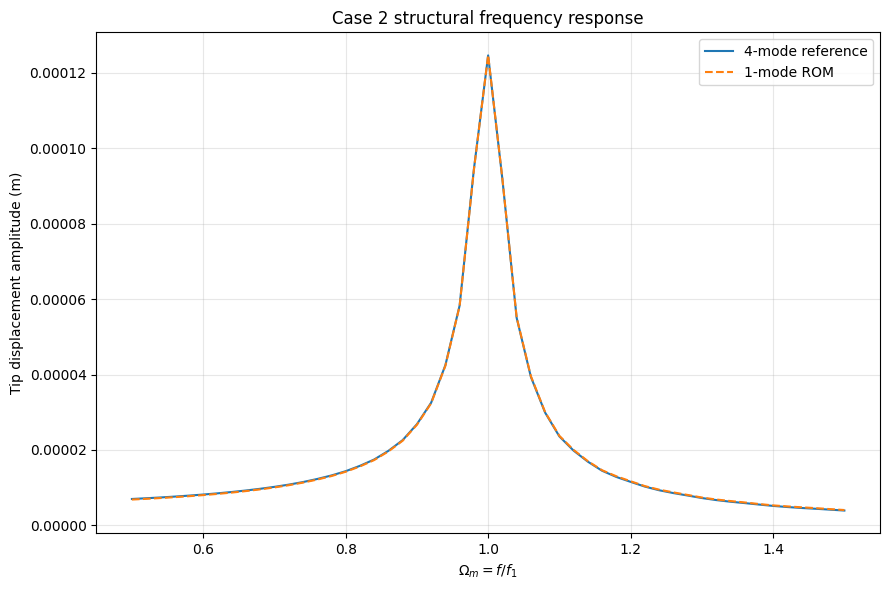

In [11]:
plt.figure(
    figsize=(9,6)
)

plt.plot(
    case2_sweep["Omega"],
    case2_sweep["amp_multi_m"],
    label="4-mode reference"
)

plt.plot(
    case2_sweep["Omega"],
    case2_sweep["amp_rom_m"],
    "--",
    label="1-mode ROM"
)

plt.xlabel(
    r"$\Omega_m=f/f_1$"
)

plt.ylabel(
    "Tip displacement amplitude (m)"
)

plt.title(
    "Case 2 structural frequency response"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [12]:
print(
    "Median relative ROM error:",
    case2_sweep[
        "relative_error"
    ].median()
)

print(
    "Maximum relative ROM error:",
    case2_sweep[
        "relative_error"
    ].max()
)

Median relative ROM error: 0.014277790368240518
Maximum relative ROM error: 0.039352014483285784


In [13]:
# Case 2B — Damping and Magnetic-Stiffness Coupling Sweeps

Case 2A established that the first structural mode accurately reproduces the
four-mode reference over

\[
0.5\le\Omega_m\le1.5.
\]

Case 2B keeps the validated first-mode ROM and varies two independent
dimensionless quantities:

1. modal damping ratio,
   \[
   \zeta_m;
   \]

2. magnetic stiffness coupling,
   \[
   \Pi_{C,m}
   =
   \frac{\Delta k_{\mathrm{mag}}}{k_1}.
   \]

The effective modal stiffness is defined as

\[
k_{\mathrm{eff}}
=
k_1
\left(
1+\Pi_{C,m}
\right).
\]

The corresponding natural frequency becomes

\[
\omega_{n,m}
=
\sqrt{
\frac{k_{\mathrm{eff}}}{m_1}
}.
\]

Magnetic actuator forcing remains separate from magnetic stiffness coupling.

The objectives are to:

- characterize resonance suppression as damping increases;
- examine frequency shifting under magnetic stiffening and softening;
- test whether frequency normalization removes the stiffness-induced dimensional shift;
- retain the damping-matched condition
  \[
  \zeta_m=0.78
  \]
  for later Case-1/Case-2 comparison.

SyntaxError: invalid decimal literal (2863799278.py, line 3)

In [14]:
required_case2b = [
    "CASE2",
    "m1",
    "k1",
    "omega1",
    "f1",
    "magnetic_force"
]

missing = [
    name
    for name in required_case2b
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Case 2B prerequisites missing: "
        + ", ".join(missing)
        + ". Re-run the Case 2A setup cells."
    )

print("Case 2B prerequisites: OK")

Case 2B prerequisites: OK


In [15]:
ZETA_SWEEP = np.array([
    0.02,
    0.05,
    0.10,
    0.30,
    0.50,
    0.78
])

print("Damping cases:", ZETA_SWEEP)

Damping cases: [0.02 0.05 0.1  0.3  0.5  0.78]


In [16]:
OMEGA_B = np.linspace(
    0.0,
    2.5,
    1001
)

def normalized_response(
    Omega,
    zeta
):

    return (
        1.0
        /
        np.sqrt(
            (
                1.0
                -
                Omega**2
            )**2
            +
            (
                2.0
                *
                zeta
                *
                Omega
            )**2
        )
    )

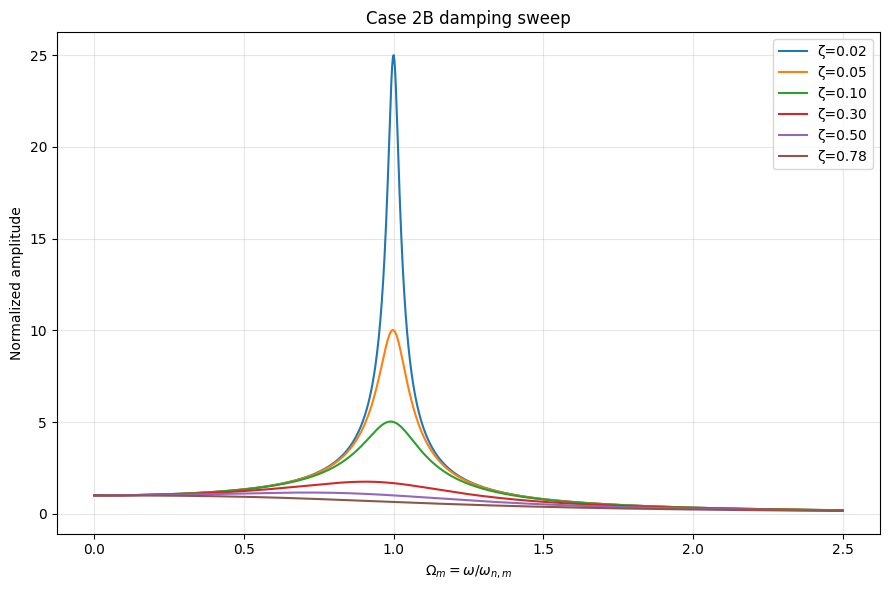

In [17]:
plt.figure(
    figsize=(9,6)
)

for zeta in ZETA_SWEEP:

    H = normalized_response(
        OMEGA_B,
        zeta
    )

    plt.plot(
        OMEGA_B,
        H,
        label=f"ζ={zeta:.2f}"
    )

plt.xlabel(
    r"$\Omega_m=\omega/\omega_{n,m}$"
)

plt.ylabel(
    "Normalized amplitude"
)

plt.title(
    "Case 2B damping sweep"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [18]:
ZETA_RES_LIMIT = 1 / np.sqrt(2)

damping_rows = []

for zeta in ZETA_SWEEP:

    H = normalized_response(
        OMEGA_B,
        zeta
    )

    idx_peak = np.argmax(H)

    peak_Omega = (
        OMEGA_B[idx_peak]
    )

    peak_amp = (
        H[idx_peak]
    )

    finite_resonance = (
        zeta
        <
        ZETA_RES_LIMIT
    )

    if finite_resonance:

        analytic_Omega_r = (
            np.sqrt(
                1
                -
                2*zeta**2
            )
        )

    else:

        analytic_Omega_r = np.nan

    damping_rows.append({

        "zeta":
            zeta,

        "finite_resonance":
            finite_resonance,

        "peak_Omega_numeric":
            peak_Omega,

        "peak_amp":
            peak_amp,

        "Omega_r_analytic":
            analytic_Omega_r,

        "Q_modal_equiv":
            1/(2*zeta)
    })


case2b_damping = pd.DataFrame(
    damping_rows
)

case2b_damping

,zeta,finite_resonance,peak_Omega_numeric,peak_amp,Omega_r_analytic,Q_modal_equiv
0,0.02,True,1.0000,25.000000,0.999600,25.000000
1,0.05,True,0.9975,10.012523,0.997497,10.000000
2,0.10,True,0.9900,5.025188,0.989949,5.000000
3,0.30,True,0.9050,1.747139,0.905539,1.666667
4,0.50,True,0.7075,1.154700,0.707107,1.000000
5,0.78,False,0.0000,1.000000,NaN,0.641026


In [19]:
ZETA_MATCH = 0.78

H_MATCHED = normalized_response(
    OMEGA_B,
    ZETA_MATCH
)

matched_summary = (
    case2b_damping[
        np.isclose(
            case2b_damping["zeta"],
            ZETA_MATCH
        )
    ]
)

matched_summary

,zeta,finite_resonance,peak_Omega_numeric,peak_amp,Omega_r_analytic,Q_modal_equiv
5,0.78,False,0.0,1.0,NaN,0.641026


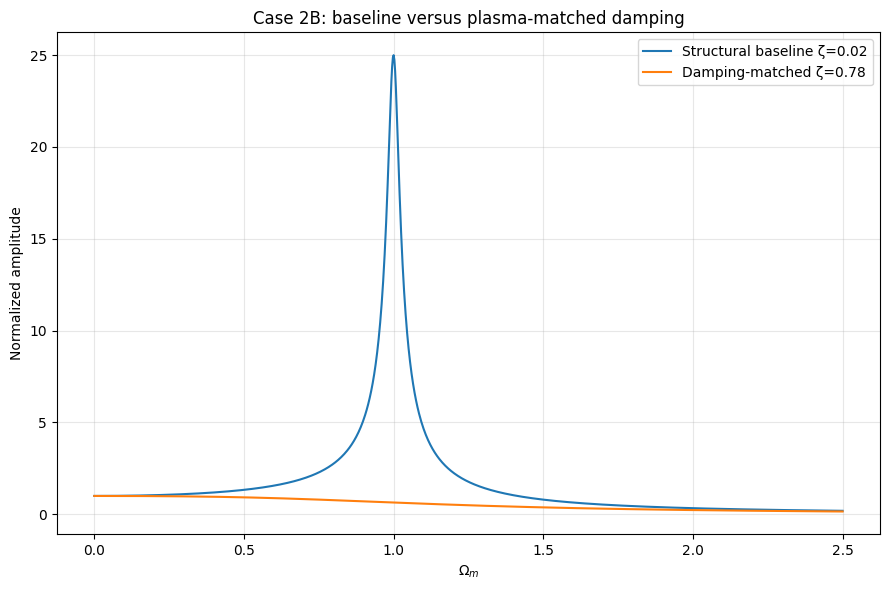

In [20]:
H_BASELINE = normalized_response(
    OMEGA_B,
    0.02
)

plt.figure(
    figsize=(9,6)
)

plt.plot(
    OMEGA_B,
    H_BASELINE,
    label="Structural baseline ζ=0.02"
)

plt.plot(
    OMEGA_B,
    H_MATCHED,
    label="Damping-matched ζ=0.78"
)

plt.xlabel(
    r"$\Omega_m$"
)

plt.ylabel(
    "Normalized amplitude"
)

plt.title(
    "Case 2B: baseline versus plasma-matched damping"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [21]:
PIC_SWEEP = np.array([
    -0.10,
    -0.05,
     0.00,
     0.05,
     0.10
])

print(
    "Magnetic stiffness coupling cases:",
    PIC_SWEEP
)

Magnetic stiffness coupling cases: [-0.1  -0.05  0.    0.05  0.1 ]


In [22]:
coupling_rows = []

for PiC in PIC_SWEEP:

    k_eff = (
        k1
        *
        (
            1.0
            +
            PiC
        )
    )

    omega_eff = np.sqrt(
        k_eff
        /
        m1
    )

    f_eff = (
        omega_eff
        /
        (2*np.pi)
    )

    coupling_rows.append({

        "Pi_C_m":
            PiC,

        "k_eff_N_m":
            k_eff,

        "omega_n_rad_s":
            omega_eff,

        "f_n_Hz":
            f_eff,

        "frequency_ratio":
            f_eff/f1
    })


case2b_coupling = pd.DataFrame(
    coupling_rows
)

case2b_coupling

,Pi_C_m,k_eff_N_m,omega_n_rad_s,f_n_Hz,frequency_ratio
0,-0.10,3501.021306,1950.334359,310.405354,0.948683
1,-0.05,3695.522490,2003.778073,318.911185,0.974679
2,0.00,3890.023673,2055.832925,327.195972,1.000000
3,0.05,4084.524857,2106.601876,335.276102,1.024695
4,0.10,4279.026041,2156.175762,343.166031,1.048809


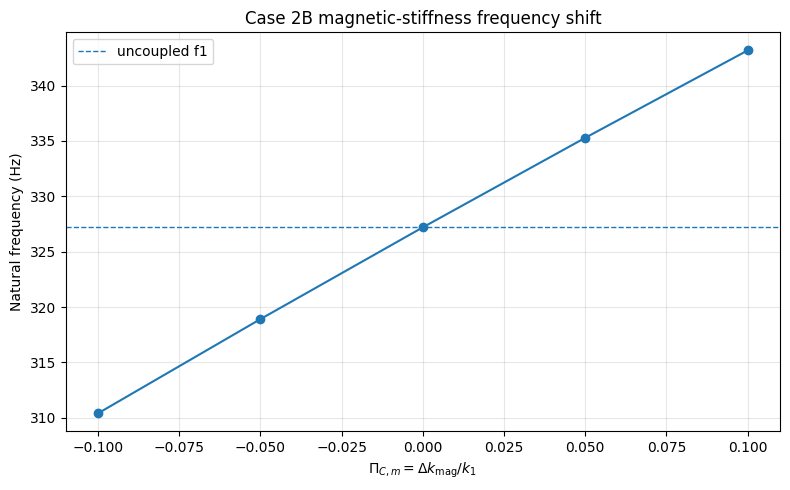

In [23]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    case2b_coupling[
        "Pi_C_m"
    ],
    case2b_coupling[
        "f_n_Hz"
    ],
    marker="o"
)

plt.axhline(
    f1,
    linestyle="--",
    linewidth=1,
    label="uncoupled f1"
)

plt.xlabel(
    r"$\Pi_{C,m}=\Delta k_{\mathrm{mag}}/k_1$"
)

plt.ylabel(
    "Natural frequency (Hz)"
)

plt.title(
    "Case 2B magnetic-stiffness frequency shift"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [24]:
freq_dim = np.linspace(
    0.5*f1,
    1.5*f1,
    801
)

F0 = (
    CASE2["K_F_N_A"]
    *
    CASE2["I0_A"]
)

coupled_frf_rows = []

for PiC in PIC_SWEEP:

    k_eff = (
        k1
        *
        (
            1 + PiC
        )
    )

    omega_eff = np.sqrt(
        k_eff/m1
    )

    c_eff = (
        2
        *
        0.02
        *
        m1
        *
        omega_eff
    )

    omega = (
        2*np.pi
        *
        freq_dim
    )

    X = (
        F0
        /
        np.sqrt(
            (
                k_eff
                -
                m1
                *
                omega**2
            )**2
            +
            (
                c_eff
                *
                omega
            )**2
        )
    )

    for f, x in zip(
        freq_dim,
        X
    ):

        coupled_frf_rows.append({

            "Pi_C_m":
                PiC,

            "freq_Hz":
                f,

            "f_n_Hz":
                omega_eff/(2*np.pi),

            "amp_m":
                x
        })


case2b_coupled_frf = pd.DataFrame(
    coupled_frf_rows
)

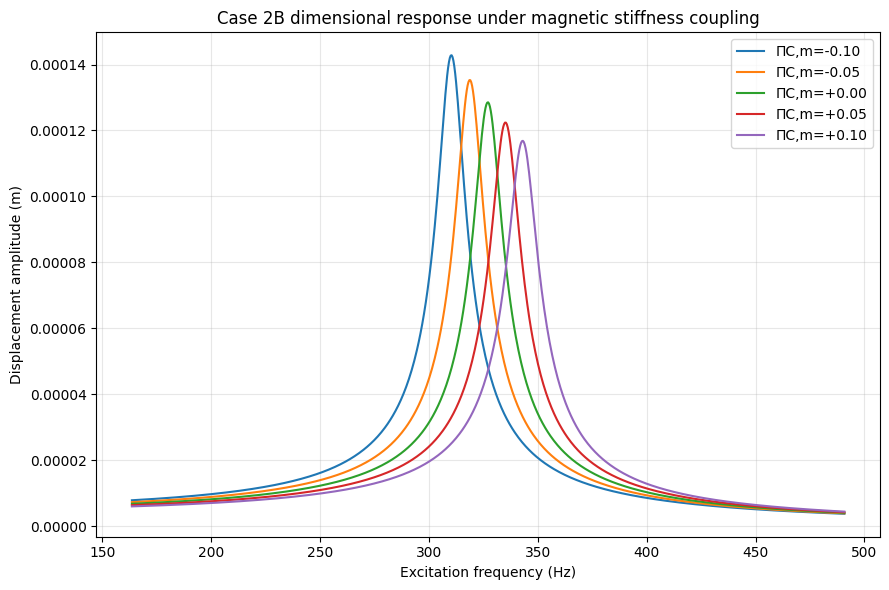

In [25]:
plt.figure(
    figsize=(9,6)
)

for PiC in PIC_SWEEP:

    d = (
        case2b_coupled_frf[
            case2b_coupled_frf[
                "Pi_C_m"
            ]
            == PiC
        ]
    )

    plt.plot(
        d["freq_Hz"],
        d["amp_m"],
        label=f"ΠC,m={PiC:+.2f}"
    )

plt.xlabel(
    "Excitation frequency (Hz)"
)

plt.ylabel(
    "Displacement amplitude (m)"
)

plt.title(
    "Case 2B dimensional response under magnetic stiffness coupling"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [26]:
collapse_rows = []

for PiC in PIC_SWEEP:

    d = (
        case2b_coupled_frf[
            case2b_coupled_frf[
                "Pi_C_m"
            ]
            == PiC
        ].copy()
    )

    k_eff = (
        k1
        *
        (
            1 + PiC
        )
    )

    f_eff = (
        d["f_n_Hz"]
        .iloc[0]
    )

    X_static = (
        F0/k_eff
    )

    d["Omega"] = (
        d["freq_Hz"]
        /
        f_eff
    )

    d["H_norm"] = (
        d["amp_m"]
        /
        X_static
    )

    collapse_rows.append(
        d[
            [
                "Pi_C_m",
                "Omega",
                "H_norm"
            ]
        ]
    )


case2b_collapse = pd.concat(
    collapse_rows,
    ignore_index=True
)

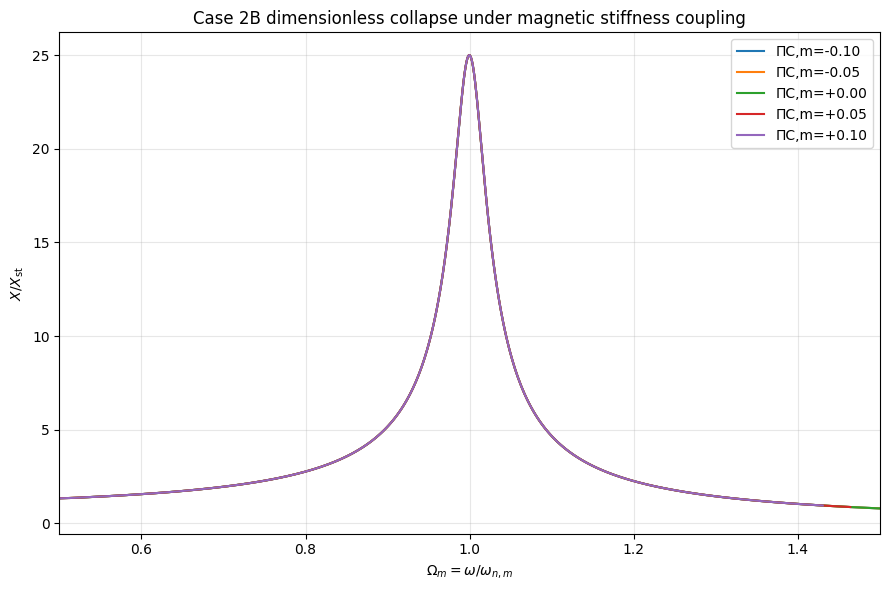

In [27]:
plt.figure(
    figsize=(9,6)
)

for PiC in PIC_SWEEP:

    d = (
        case2b_collapse[
            case2b_collapse[
                "Pi_C_m"
            ]
            == PiC
        ]
    )

    plt.plot(
        d["Omega"],
        d["H_norm"],
        label=f"ΠC,m={PiC:+.2f}"
    )

plt.xlim(
    0.5,
    1.5
)

plt.xlabel(
    r"$\Omega_m=\omega/\omega_{n,m}$"
)

plt.ylabel(
    r"$X/X_{\mathrm{st}}$"
)

plt.title(
    "Case 2B dimensionless collapse under magnetic stiffness coupling"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [28]:
OMEGA_COMMON = np.linspace(
    0.55,
    1.45,
    401
)

reference = (
    case2b_collapse[
        case2b_collapse[
            "Pi_C_m"
        ]
        == 0.0
    ]
)

H_REF = np.interp(
    OMEGA_COMMON,
    reference["Omega"],
    reference["H_norm"]
)

collapse_metric_rows = []

for PiC in PIC_SWEEP:

    d = (
        case2b_collapse[
            case2b_collapse[
                "Pi_C_m"
            ]
            == PiC
        ]
    )

    H = np.interp(
        OMEGA_COMMON,
        d["Omega"],
        d["H_norm"]
    )

    E_collapse = np.sqrt(
        np.mean(
            (
                H
                -
                H_REF
            )**2
        )
    )

    collapse_metric_rows.append({

        "Pi_C_m":
            PiC,

        "E_collapse":
            E_collapse
    })


case2b_collapse_metric = pd.DataFrame(
    collapse_metric_rows
)

case2b_collapse_metric

,Pi_C_m,E_collapse
0,-0.10,0.000488
1,-0.05,0.000785
2,0.00,0.000000
3,0.05,0.000689
4,0.10,0.004644


In [29]:
X_REF_M = 1e-3

PI_F_M = (
    F0
    /
    (
        k1
        *
        X_REF_M
    )
)

print(
    f"Magnetic force amplitude F0 = "
    f"{F0:.6f} N"
)

print(
    f"Reference displacement = "
    f"{X_REF_M*1e3:.3f} mm"
)

print(
    f"Pi_F,m = "
    f"{PI_F_M:.6e}"
)

Magnetic force amplitude F0 = 0.020000 N
Reference displacement = 1.000 mm
Pi_F,m = 5.141357e-03


In [30]:
case2b_matched_curve = pd.DataFrame({
    "Omega": OMEGA_B,
    "H_norm": H_MATCHED,
    "zeta": ZETA_MATCH
})

case2b_matched_curve.head()

,Omega,H_norm,zeta
0,0.0000,1.000000,0.78
1,0.0025,0.999999,0.78
2,0.0050,0.999995,0.78
3,0.0075,0.999988,0.78
4,0.0100,0.999978,0.78


In [31]:
print("CASE 2B SUMMARY")
print("--------------------------------")

print(
    "Damping sweep:",
    ZETA_SWEEP
)

print(
    "\nPlasma-matched damping:",
    ZETA_MATCH
)

print(
    "Finite resonance at matched damping:",
    bool(
        ZETA_MATCH
        <
        ZETA_RES_LIMIT
    )
)

print(
    "\nMagnetic stiffness coupling range:",
    f"{PIC_SWEEP.min():+.2f}",
    "to",
    f"{PIC_SWEEP.max():+.2f}"
)

print(
    "Frequency range under coupling:",
    f"{case2b_coupling['f_n_Hz'].min():.2f}",
    "to",
    f"{case2b_coupling['f_n_Hz'].max():.2f}",
    "Hz"
)

print(
    "\nMaximum normalized collapse error:",
    case2b_collapse_metric[
        "E_collapse"
    ].max()
)

print(
    "\nStructural forcing ratio Pi_F,m:",
    PI_F_M
)

CASE 2B SUMMARY
--------------------------------
Damping sweep: [0.02 0.05 0.1  0.3  0.5  0.78]

Plasma-matched damping: 0.78
Finite resonance at matched damping: False

Magnetic stiffness coupling range: -0.10 to +0.10
Frequency range under coupling: 310.41 to 343.17 Hz

Maximum normalized collapse error: 0.004643933938592921

Structural forcing ratio Pi_F,m: 0.005141356886236227


In [32]:
from pathlib import Path
import json

OUT2 = Path(
    "mea_case2_outputs"
)

OUT2.mkdir(
    exist_ok=True
)


case2b_damping.to_csv(
    OUT2
    /
    "case2b_damping_sweep.csv",
    index=False
)

case2b_coupling.to_csv(
    OUT2
    /
    "case2b_stiffness_coupling.csv",
    index=False
)

case2b_collapse_metric.to_csv(
    OUT2
    /
    "case2b_collapse_metric.csv",
    index=False
)

case2b_matched_curve.to_csv(
    OUT2
    /
    "case2b_plasma_matched_curve.csv",
    index=False
)


case2b_summary = {

    "zeta_sweep":
        ZETA_SWEEP.tolist(),

    "plasma_matched_zeta":
        ZETA_MATCH,

    "stiffness_coupling_range":
        [
            float(
                PIC_SWEEP.min()
            ),
            float(
                PIC_SWEEP.max()
            )
        ],

    "frequency_range_Hz":
        [
            float(
                case2b_coupling[
                    "f_n_Hz"
                ].min()
            ),
            float(
                case2b_coupling[
                    "f_n_Hz"
                ].max()
            )
        ],

    "max_collapse_error":
        float(
            case2b_collapse_metric[
                "E_collapse"
            ].max()
        ),

    "Pi_F_m":
        float(
            PI_F_M
        ),

    "interpretation":
        (
            "Validated first-mode structural ROM "
            "swept across damping and magnetic "
            "stiffness coupling. Frequency shifts "
            "are removed by local normalization "
            "when damping is held fixed."
        )
}


with open(
    OUT2
    /
    "case2b_summary.json",
    "w"
) as f:

    json.dump(
        case2b_summary,
        f,
        indent=2
    )


print(
    "Case 2B evidence exported to:",
    OUT2.resolve()
)

Case 2B evidence exported to: /content/mea_case2_outputs


In [ ]:
# ============================================================
# MEA FIGURE 3 — Preflight
# Inspect existing Case 2 objects only
# ============================================================

required_candidates = [
    "L",
    "b",
    "h",
    "E",
    "rho",
    "m1",
    "k1",
    "c1",
    "zeta1",
]

print("Core Case 2 objects:")
for name in required_candidates:
    print(f"{name:24s}: {name in globals()}")

print("\nLikely Case 2A / Case 2B objects:")

keywords = (
    "freq",
    "omega",
    "rom",
    "multi",
    "mode",
    "zeta",
    "stiff",
    "coupling",
    "collapse",
    "case2",
)

matches = []

for name, obj in globals().items():
    lname = name.lower()

    if (
        any(k in lname for k in keywords)
        and not name.startswith("_")
    ):
        typename = type(obj).__name__

        if hasattr(obj, "shape"):
            detail = f"shape={obj.shape}"
        elif isinstance(obj, (list, tuple, dict)):
            detail = f"len={len(obj)}"
        else:
            detail = ""

        matches.append(
            (name, typename, detail)
        )

for name, typename, detail in sorted(matches):
    print(f"{name:36s} {typename:18s} {detail}")

Core Case 2 objects:
L                       : True
b                       : True
h                       : True
E                       : True
rho                     : True
m1                      : True
k1                      : True
c1                      : True
zeta1                   : True

Likely Case 2A / Case 2B objects:


RuntimeError: dictionary changed size during iteration

In [ ]:
# ============================================================
# MEA FIGURE 3 — Safe discovery of Case 2A / Case 2B objects
# ============================================================

keywords = (
    "freq",
    "omega",
    "rom",
    "multi",
    "mode",
    "zeta",
    "stiff",
    "coupling",
    "collapse",
    "case2",
)

matches = []

# Snapshot prevents:
# RuntimeError: dictionary changed size during iteration
global_snapshot = list(globals().items())

for name, obj in global_snapshot:

    lname = name.lower()

    if (
        any(k in lname for k in keywords)
        and not name.startswith("_")
    ):

        typename = type(obj).__name__

        if hasattr(obj, "shape"):
            detail = f"shape={obj.shape}"

        elif isinstance(obj, (list, tuple, dict)):
            detail = f"len={len(obj)}"

        else:
            detail = ""

        matches.append(
            (name, typename, detail)
        )

for name, typename, detail in sorted(matches):
    print(
        f"{name:36s} "
        f"{typename:18s} "
        f"{detail}"
    )

CASE2                                dict               len=8
E_collapse                           float64            shape=()
NMODES                               int                
OMEGA_B                              ndarray            shape=(1001,)
OMEGA_COMMON                         ndarray            shape=(401,)
OMEGA_SWEEP                          ndarray            shape=(51,)
Omega                                float64            shape=()
ZETA_MATCH                           float              
ZETA_RES_LIMIT                       float64            shape=()
ZETA_SWEEP                           ndarray            shape=(6,)
analytic_Omega_r                     float              
case2_rows                           list               len=51
case2_sweep                          DataFrame          shape=(51, 5)
case2b_collapse                      DataFrame          shape=(4005, 3)
case2b_collapse_metric               DataFrame          shape=(5, 2)
case2b_coupled_frf      

In [ ]:
# ============================================================
# MEA FIGURE 3 — Inspect final source DataFrames
# ============================================================

for name in [
    "case2_sweep",
    "case2b_collapse",
    "case2b_collapse_metric",
    "case2b_coupling",
]:
    obj = globals()[name]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print("shape:", obj.shape)
    print("columns:", list(obj.columns))
    print(obj.head())


case2_sweep
shape: (51, 5)
columns: ['freq_Hz', 'Omega', 'amp_multi_m', 'amp_rom_m', 'relative_error']
      freq_Hz  Omega  amp_multi_m  amp_rom_m  relative_error
0  163.597986   0.50     0.000007   0.000007        0.021776
1  170.141906   0.52     0.000007   0.000007        0.021273
2  176.685825   0.54     0.000007   0.000007        0.020585
3  183.229744   0.56     0.000008   0.000007        0.020052
4  189.773664   0.58     0.000008   0.000008        0.019466

case2b_collapse
shape: (4005, 3)
columns: ['Pi_C_m', 'Omega', 'H_norm']
   Pi_C_m     Omega    H_norm
0    -0.1  0.527046  1.384026
1    -0.1  0.528364  1.386691
2    -0.1  0.529682  1.389372
3    -0.1  0.530999  1.392071
4    -0.1  0.532317  1.394787

case2b_collapse_metric
shape: (5, 2)
columns: ['Pi_C_m', 'E_collapse']
   Pi_C_m  E_collapse
0   -0.10    0.000488
1   -0.05    0.000785
2    0.00    0.000000
3    0.05    0.000689
4    0.10    0.004644

case2b_coupling
shape: (5, 5)
columns: ['Pi_C_m', 'k_eff_N_m', 'omega_n_

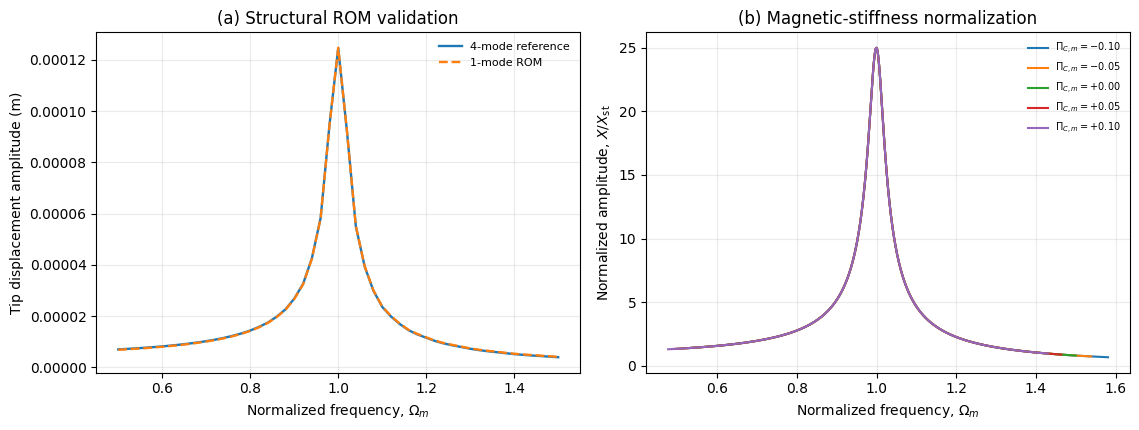

Saved:
  fig03_structural_validation.pdf
  fig03_structural_validation.png

Structural ROM validation:
median relative error = 1.428%
maximum relative error = 3.935%

Magnetic-stiffness collapse metrics:
   Pi_C_m  E_collapse
0   -0.10    0.000488
1   -0.05    0.000785
2    0.00    0.000000
3    0.05    0.000689
4    0.10    0.004644

Maximum collapse error = 0.004644

Coupled natural-frequency range:
310.405 Hz to 343.166 Hz


In [ ]:
# ============================================================
# MEA PUBLICATION FIGURE 3
# Structural ROM validation and magnetic-stiffness normalization
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Source data
# ------------------------------------------------------------

df_val = case2_sweep.copy()
df_col = case2b_collapse.copy()

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.4)
)

ax_val, ax_col = axes

# ------------------------------------------------------------
# Panel (a): first-mode ROM vs four-mode reference
# ------------------------------------------------------------

ax_val.plot(
    df_val["Omega"],
    df_val["amp_multi_m"],
    linewidth=1.7,
    label="4-mode reference"
)

ax_val.plot(
    df_val["Omega"],
    df_val["amp_rom_m"],
    linestyle="--",
    linewidth=1.7,
    label="1-mode ROM"
)

ax_val.set_title(
    "(a) Structural ROM validation"
)

ax_val.set_xlabel(
    r"Normalized frequency, $\Omega_m$"
)

ax_val.set_ylabel(
    "Tip displacement amplitude (m)"
)

ax_val.grid(
    alpha=0.25
)

ax_val.legend(
    fontsize=8,
    frameon=False
)

# ------------------------------------------------------------
# Panel (b): normalized collapse under stiffness coupling
# ------------------------------------------------------------

coupling_values = sorted(
    df_col["Pi_C_m"].unique()
)

for pi_c in coupling_values:

    subset = (
        df_col[
            np.isclose(
                df_col["Pi_C_m"],
                pi_c
            )
        ]
        .sort_values("Omega")
    )

    ax_col.plot(
        subset["Omega"],
        subset["H_norm"],
        linewidth=1.5,
        label=rf"$\Pi_{{C,m}}={pi_c:+.2f}$"
    )

ax_col.set_title(
    "(b) Magnetic-stiffness normalization"
)

ax_col.set_xlabel(
    r"Normalized frequency, $\Omega_m$"
)

ax_col.set_ylabel(
    r"Normalized amplitude, $X/X_{\mathrm{st}}$"
)

ax_col.grid(
    alpha=0.25
)

ax_col.legend(
    fontsize=7,
    frameon=False
)

# ------------------------------------------------------------
# Final layout and export
# ------------------------------------------------------------

plt.tight_layout()

fig.savefig(
    "fig03_structural_validation.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "fig03_structural_validation.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Print key metrics for audit
# ------------------------------------------------------------

median_error = df_val["relative_error"].median()
max_error = df_val["relative_error"].max()

print("Saved:")
print("  fig03_structural_validation.pdf")
print("  fig03_structural_validation.png")

print("\nStructural ROM validation:")
print(
    f"median relative error = "
    f"{100*median_error:.3f}%"
)
print(
    f"maximum relative error = "
    f"{100*max_error:.3f}%"
)

print("\nMagnetic-stiffness collapse metrics:")
print(case2b_collapse_metric)

print(
    "\nMaximum collapse error = "
    f"{case2b_collapse_metric['E_collapse'].max():.6f}"
)

print("\nCoupled natural-frequency range:")
print(
    f"{case2b_coupling['f_n_Hz'].min():.3f} Hz "
    f"to "
    f"{case2b_coupling['f_n_Hz'].max():.3f} Hz"
)

In [33]:
# ============================================================
# CASE 2B — DAMPING-TREATMENT AUDIT
# Determine exactly how damping is handled during the
# magnetic-stiffness sweep.
# ============================================================

import inspect

print("=" * 72)
print("Core quantities")
print("=" * 72)

for name in [
    "m1",
    "k1",
    "c1",
    "zeta1",
    "omega1",
]:
    if name in globals():
        print(f"{name:16s}: {globals()[name]}")
    else:
        print(f"{name:16s}: NOT FOUND")


print("\n" + "=" * 72)
print("Relevant Case 2B functions")
print("=" * 72)

for name in [
    "run_case2_frequency",
    "rom1_rhs",
    "multimode_rhs",
]:
    if name in globals():

        fn = globals()[name]

        print(f"\n--- {name} ---")

        try:
            print("signature:", inspect.signature(fn))
        except Exception as exc:
            print("signature unavailable:", exc)

        try:
            print(inspect.getsource(fn))
        except Exception as exc:
            print("source unavailable:", exc)


print("\n" + "=" * 72)
print("Case 2B coupling table")
print("=" * 72)

if "case2b_coupling" in globals():
    print(case2b_coupling.to_string(index=False))
else:
    print("case2b_coupling: NOT FOUND")


print("\n" + "=" * 72)
print("Search likely stiffness/damping variables")
print("=" * 72)

keywords = (
    "coupl",
    "stiff",
    "damp",
    "zeta",
    "c_eff",
    "omega_eff",
    "collapse",
)

snapshot = list(globals().items())

for name, obj in sorted(snapshot):
    lname = name.lower()

    if (
        any(k in lname for k in keywords)
        and not name.startswith("_")
    ):
        if hasattr(obj, "shape"):
            print(
                f"{name:36s} "
                f"{type(obj).__name__:18s} "
                f"shape={obj.shape}"
            )
        elif isinstance(obj, (dict, list, tuple)):
            print(
                f"{name:36s} "
                f"{type(obj).__name__:18s} "
                f"len={len(obj)}"
            )
        elif isinstance(obj, (int, float)):
            print(
                f"{name:36s} "
                f"{type(obj).__name__:18s} "
                f"{obj}"
            )

Core quantities
m1              : 0.0009204
k1              : 3890.023673233306
c1              : 0.07568754496051709
zeta1           : 0.02
omega1          : 2055.832924829343

Relevant Case 2B functions

--- run_case2_frequency ---
signature: (freq_Hz, I_amp=None)
def run_case2_frequency(
    freq_Hz,
    I_amp=None
):

    if I_amp is None:
        I_amp = CASE2["I0_A"]

    period = 1/freq_Hz

    t_end = 40*period

    # Multi-mode reference

    sol_multi = solve_ivp(
        multimode_rhs,
        (0, t_end),
        np.zeros(2*NMODES),
        args=(
            freq_Hz,
            I_amp
        ),
        max_step=period/100,
        rtol=1e-8,
        atol=1e-10
    )

    # tip displacement:
    # modes normalized to unit tip
    w_tip_multi = (
        sol_multi.y[
            :NMODES
        ].sum(axis=0)
    )

    amp_multi = steady_state_amplitude(
        sol_multi.t,
        w_tip_multi,
        freq_Hz
    )

    # First-mode ROM

    sol_rom = solve_ivp(
        ro

In [34]:
# ============================================================
# CASE 2B — FINAL DAMPING-TREATMENT AUDIT
# Inspect generated sweep data and nearby source variables
# ============================================================

import inspect
import numpy as np

print("=" * 72)
print("Current terminal Case 2B variables")
print("=" * 72)

for name in [
    "c_eff",
    "omega_eff",
    "zeta",
    "zeta1",
    "ZETA_MATCH",
]:
    if name in globals():
        print(f"{name:18s}: {globals()[name]}")


print("\n" + "=" * 72)
print("case2b_coupled_frf")
print("=" * 72)

print("columns:", list(case2b_coupled_frf.columns))
print(case2b_coupled_frf.head(12).to_string(index=False))


print("\n" + "=" * 72)
print("case2b_collapse")
print("=" * 72)

print("columns:", list(case2b_collapse.columns))
print(case2b_collapse.head(12).to_string(index=False))


print("\n" + "=" * 72)
print("Infer effective damping if dimensional FRF data permit")
print("=" * 72)

# Known possibilities for each stiffness condition:
# A: c_eff = c1 -> zeta varies
# B: zeta = zeta1 -> c_eff varies
# C: zeta = ZETA_MATCH -> c_eff varies

for _, row in case2b_coupling.iterrows():

    Pi = float(row["Pi_C_m"])
    wn = float(row["omega_n_rad_s"])

    zeta_if_c1_fixed = (
        c1 / (2.0 * m1 * wn)
    )

    c_if_zeta1_fixed = (
        2.0 * zeta1 * m1 * wn
    )

    c_if_match_fixed = (
        2.0 * ZETA_MATCH * m1 * wn
    )

    print(
        f"Pi={Pi:+.2f} | "
        f"zeta(c=c1)={zeta_if_c1_fixed:.8f} | "
        f"c(zeta=0.02)={c_if_zeta1_fixed:.8f} | "
        f"c(zeta=0.78)={c_if_match_fixed:.8f}"
    )

Current terminal Case 2B variables
c_eff             : 0.07938176685086648
omega_eff         : 2156.175761920537
zeta              : 0.78
zeta1             : 0.02
ZETA_MATCH        : 0.78

case2b_coupled_frf
columns: ['Pi_C_m', 'freq_Hz', 'f_n_Hz', 'amp_m']
 Pi_C_m    freq_Hz     f_n_Hz    amp_m
   -0.1 163.597986 310.405354 0.000008
   -0.1 164.006981 310.405354 0.000008
   -0.1 164.415976 310.405354 0.000008
   -0.1 164.824971 310.405354 0.000008
   -0.1 165.233966 310.405354 0.000008
   -0.1 165.642961 310.405354 0.000008
   -0.1 166.051956 310.405354 0.000008
   -0.1 166.460951 310.405354 0.000008
   -0.1 166.869946 310.405354 0.000008
   -0.1 167.278941 310.405354 0.000008
   -0.1 167.687936 310.405354 0.000008
   -0.1 168.096931 310.405354 0.000008

case2b_collapse
columns: ['Pi_C_m', 'Omega', 'H_norm']
 Pi_C_m    Omega   H_norm
   -0.1 0.527046 1.384026
   -0.1 0.528364 1.386691
   -0.1 0.529682 1.389372
   -0.1 0.530999 1.392071
   -0.1 0.532317 1.394787
   -0.1 0.533634 1.3975